In [1]:
!pip -q install kaggle

import os, json

os.environ['KAGGLE_USERNAME'] = 'aarayann'
os.environ['KAGGLE_KEY'] = 'KGAT_6770c194baa8a460b3fe0314ddfb1f97'

kaggle_data = {
    "username": os.environ['KAGGLE_USERNAME'],
    "key": os.environ['KAGGLE_KEY']
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_data, f)

# Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

DATASET_SLUG = "aarayann/indian-youtube-clickbait-datasetwith-metadata"

!mkdir -p /content/kaggle_dataset
!kaggle datasets download -d $DATASET_SLUG -p /content/kaggle_dataset --unzip

# Check files
!ls -lah /content/kaggle_dataset

Dataset URL: https://www.kaggle.com/datasets/aarayann/indian-youtube-clickbait-datasetwith-metadata
License(s): unknown
100% 306M/306M [00:01<00:00, 250MB/s]

total 125M
drwxr-xr-x 3 root root 4.0K Apr 18 17:42 .
drwxr-xr-x 1 root root 4.0K Apr 18 17:29 ..
-rw-r--r-- 1 root root  62M Apr 18 17:42 dataset_complete.csv
-rw-r--r-- 1 root root  64M Apr 18 17:42 dataset_complete.jsonl
drwxr-xr-x 3 root root 4.0K Apr 18 16:31 thumbnails


In [2]:
import os
import pandas as pd

DATA_DIR = "/content/kaggle_dataset"
CSV_NAME = "dataset_complete.csv"

csv_path = os.path.join(DATA_DIR, CSV_NAME)

# Load with safer settings
df = pd.read_csv(csv_path, low_memory=False)

print("rows, cols:", df.shape)
print("\ncolumns:", list(df.columns))

df.head(3)

rows, cols: (2066, 29)

columns: ['video_id', 'channel_id', 'channel_title', 'channel_category', 'title', 'description', 'published_at', 'duration', 'view_count', 'like_count', 'comment_count', 'thumbnail_url', 'thumbnail_path', 'transcript_language', 'transcript_available', 'transcript_status', 'transcript_checked', 'transcript', 'label', 'label_status', 'label_confidence', 'collection_source', 'notes', 'heuristic_score', 'auto_label', 'default_audio_language', 'default_language', 'heuristic_reasons', 'tags']


,video_id,channel_id,channel_title,channel_category,title,description,published_at,duration,view_count,like_count,...,label_status,label_confidence,collection_source,notes,heuristic_score,auto_label,default_audio_language,default_language,heuristic_reasons,tags
0,3YP2qq-y-wo,UCRWFSbif-RFENbBrSiez1DA,ABP NEWS,news,Kiren Rijiju Press Conference LIVE: महिला आरक्...,Kiren Rijiju Press Conference LIVE: महिला आरक्...,2026-04-18T07:43:33Z,P0D,388,7,...,heuristic_negative,0.95,youtube_api,NaN,0.9,0,hi,en-IN,"['high_risk_category:news', 'missing_transcript']",abp news|abp news live|abp news hindi|abp news...
1,11GF1JOIZG4,UCRWFSbif-RFENbBrSiez1DA,ABP NEWS,news,Massive Protest Announcement LIVE: राहुल गांधी...,Massive Protest Announcement LIVE: राहुल गांधी...,2026-04-18T07:21:49Z,P0D,2258,18,...,heuristic_negative,0.95,youtube_api,NaN,1.4,0,hi,en-IN,"['title_has_exclamation', 'high_risk_category:...",rahul gandhi house|women protest delhi|bill fa...
2,pJk0t09MSns,UCRWFSbif-RFENbBrSiez1DA,ABP NEWS,news,Sandeep Chaudhary on Women Reservation: बिल गि...,Sandeep Chaudhary on Women Reservation: बिल गि...,2026-04-18T07:57:56Z,PT9S,12,1,...,manual_reviewed,1.00,youtube_api,User manually confirmed as clickbait after rev...,1.8,-1,hi,en-IN,"['title_has_exclamation', 'very_long_title', '...",politics news|Lok Sabha|abp news|abp news live...


In [3]:
thumb_dir = "/content/kaggle_dataset/thumbnails/thumbnails"
files = os.listdir(thumb_dir)

print("Total images:", len(files))
print("Sample files:", files[:5])

Total images: 2066
Sample files: ['yuW0VbpRzOE.jpg', 'FlFLSe2mVaU.jpg', 'EQwh2ch_XUk.jpg', 'spS-xHB3OGU.jpg', 'GC_1eNb8vo4.jpg']


In [4]:
assert "label" in df.columns, "Missing label column (expected 0/1 in 'label')."
print(df["label"].value_counts(dropna=False))

assert "thumbnail_path" in df.columns, "Missing thumbnail_path column."
print("example thumbnail_path:", df["thumbnail_path"].dropna().iloc[0])

THUMB_DIR = os.path.join(DATA_DIR, "thumbnails", "thumbnails")

# extract only filename from CSV path
filename = os.path.basename(df["thumbnail_path"].dropna().iloc[0])

thumb_example = os.path.join(THUMB_DIR, filename)

print("thumbnail exists:", os.path.exists(thumb_example), "|", thumb_example)

label
0    1427
1     639
Name: count, dtype: int64
example thumbnail_path: thumbnails/3YP2qq-y-wo.jpg
thumbnail exists: True | /content/kaggle_dataset/thumbnails/thumbnails/3YP2qq-y-wo.jpg


In [5]:
import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "/content/kaggle_dataset"
CSV_NAME = "dataset_complete.csv"

df = pd.read_csv(os.path.join(DATA_DIR, CSV_NAME))

# Fix BOM in first column name if present
bom_cols = [c for c in df.columns if c.startswith("\ufeff")]
if bom_cols:
    df = df.rename(columns={bom_cols[0]: bom_cols[0].lstrip("\ufeff")})

df.shape, df.columns.tolist()


((2066, 29),
 ['video_id',
  'channel_id',
  'channel_title',
  'channel_category',
  'title',
  'description',
  'published_at',
  'duration',
  'view_count',
  'like_count',
  'comment_count',
  'thumbnail_url',
  'thumbnail_path',
  'transcript_language',
  'transcript_available',
  'transcript_status',
  'transcript_checked',
  'transcript',
  'label',
  'label_status',
  'label_confidence',
  'collection_source',
  'notes',
  'heuristic_score',
  'auto_label',
  'default_audio_language',
  'default_language',
  'heuristic_reasons',
  'tags'])

In [6]:
import numpy as np

print("shape:", df.shape)
print("label counts:\n", df["label"].value_counts(dropna=False))

if "video_id" in df.columns:
    print("duplicate video_id rows:", int(df["video_id"].duplicated().sum()))

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("Top missing % columns:\n", missing.head(20))

bad = df[~df["label"].isin([0,1])]
print("rows with invalid label:", len(bad))


shape: (2066, 29)
label counts:
 label
0    1427
1     639
Name: count, dtype: int64
duplicate video_id rows: 0
Top missing % columns:
 notes                     72.65
tags                      22.89
description               15.63
duration                   0.29
default_audio_language     0.05
title                      0.00
channel_category           0.00
published_at               0.00
view_count                 0.00
like_count                 0.00
channel_title              0.00
channel_id                 0.00
video_id                   0.00
thumbnail_path             0.00
thumbnail_url              0.00
comment_count              0.00
transcript_language        0.00
transcript                 0.00
transcript_available       0.00
transcript_status          0.00
dtype: float64
rows with invalid label: 0


In [7]:
def _strlen(x):
    if pd.isna(x): return 0
    return len(str(x))

df["title_len"] = df["title"].map(_strlen) if "title" in df.columns else 0
df["desc_len"] = df["description"].map(_strlen) if "description" in df.columns else 0
df["transcript_len"] = df["transcript"].map(_strlen) if "transcript" in df.columns else 0

print("title_len stats:\n", df["title_len"].describe().round(2))
print("transcript_len stats:\n", df["transcript_len"].describe().round(2))

# Check empty transcripts (should be 0 if this is your 'complete' dataset)
print("empty transcript rows:", int((df["transcript_len"] == 0).sum()) if "transcript_len" in df.columns else "n/a")


title_len stats:
 count    2066.00
mean       66.29
std        22.53
min        10.00
25%        48.00
50%        66.00
75%        88.00
max       100.00
Name: title_len, dtype: float64
transcript_len stats:
 count      2066.00
mean      13485.98
std       35940.84
min           2.00
25%         721.25
50%        3256.50
75%       13565.25
max      653327.00
Name: transcript_len, dtype: float64
empty transcript rows: 0


In [8]:
# CELL 1 — Install, imports, clean data
!pip install -q transformers torch torchvision sentence-transformers \
    xgboost scikit-learn imbalanced-learn open-clip-torch Pillow \
    langdetect matplotlib seaborn tqdm

import os, json, re, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
warnings.filterwarnings("ignore")

DATA_DIR   = "/content/kaggle_dataset"
THUMB_DIR  = os.path.join(DATA_DIR, "thumbnails", "thumbnails")
CSV_PATH   = os.path.join(DATA_DIR, "dataset_complete.csv")

df = pd.read_csv(CSV_PATH, low_memory=False)
# Fix BOM
df.columns = [c.lstrip("\ufeff") for c in df.columns]

# ── Fill missing fields ──────────────────────────────────────────────────────
df["description"]  = df["description"].fillna("")
df["tags"]         = df["tags"].fillna("")
df["transcript"]   = df["transcript"].fillna("")
df["notes"]        = df["notes"].fillna("")
df["default_language"] = df["default_language"].fillna("unknown")

# ── Derived text fields ──────────────────────────────────────────────────────
df["title_len"]       = df["title"].str.len()
df["transcript_len"]  = df["transcript"].str.len()

# ── Fix thumbnail paths ──────────────────────────────────────────────────────
df["thumb_local"] = df["thumbnail_path"].apply(
    lambda p: os.path.join(THUMB_DIR, os.path.basename(str(p)))
)
df["thumb_exists"] = df["thumb_local"].apply(os.path.exists)

print(f"Total rows       : {len(df)}")
print(f"Label dist       : {df['label'].value_counts().to_dict()}")
print(f"Thumbnails found : {df['thumb_exists'].sum()} / {len(df)}")
print(f"Empty transcripts: {(df['transcript_len'] == 0).sum()}")
print(f"Ratio 0:1        : {df['label'].value_counts()[0]/df['label'].value_counts()[1]:.2f}:1")

Total rows       : 2066
Label dist       : {0: 1427, 1: 639}
Thumbnails found : 2066 / 2066
Empty transcripts: 0
Ratio 0:1        : 2.23:1


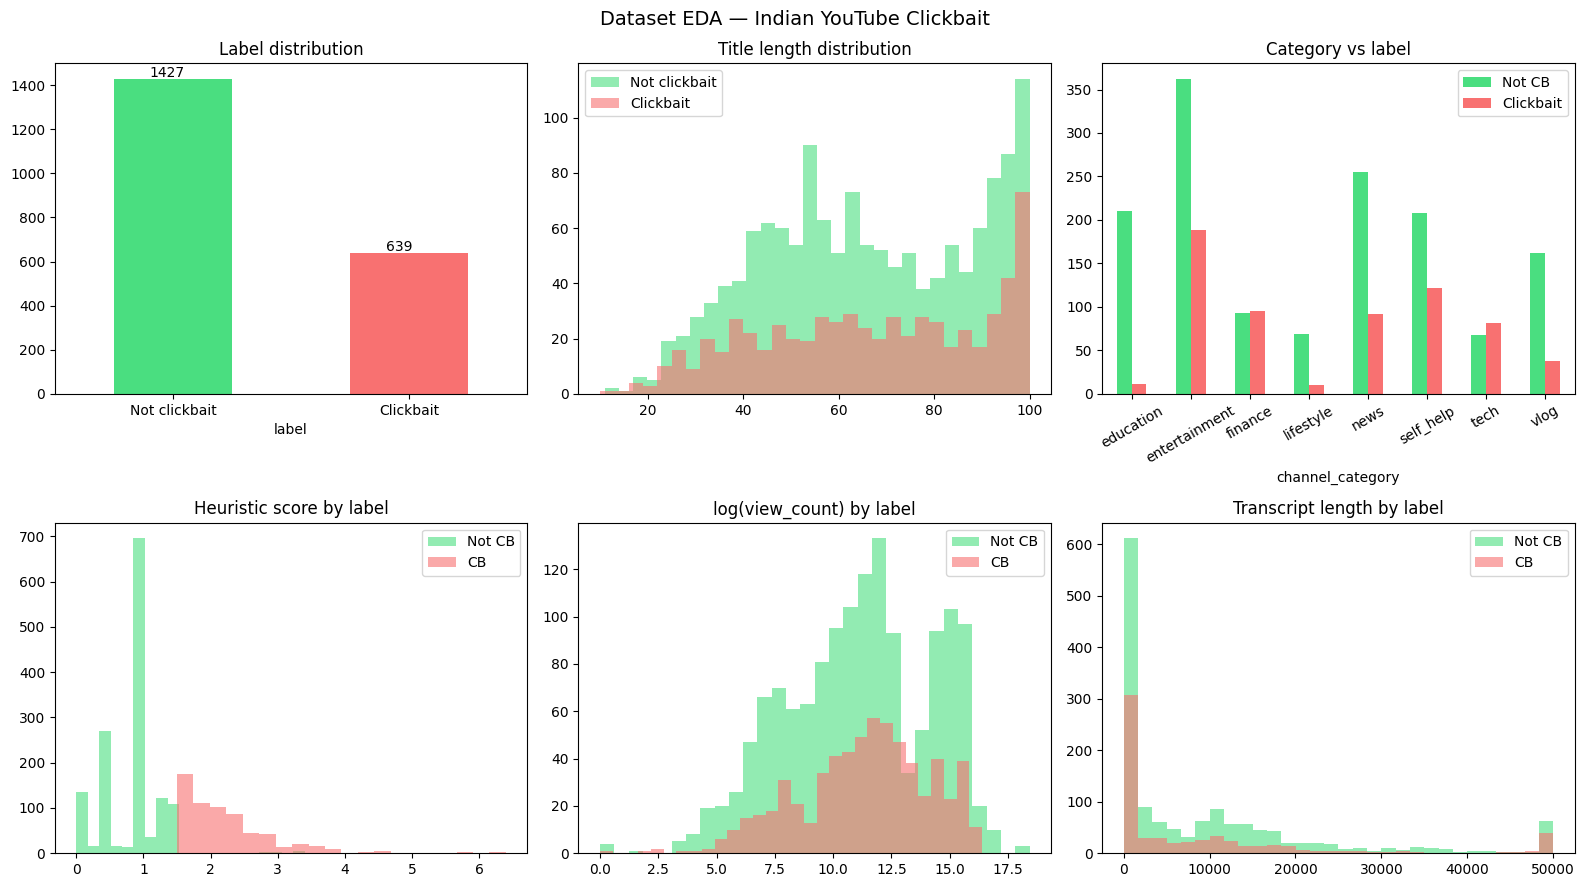

EDA saved → eda.png


In [9]:
# CELL 2 — EDA
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Dataset EDA — Indian YouTube Clickbait", fontsize=14)

# 1. Label distribution
ax = axes[0,0]
df["label"].value_counts().plot.bar(ax=ax, color=["#4ade80","#f87171"], edgecolor="none")
ax.set_title("Label distribution"); ax.set_xticklabels(["Not clickbait","Clickbait"], rotation=0)
for p in ax.patches: ax.annotate(f"{int(p.get_height())}", (p.get_x()+.15, p.get_height()+10))

# 2. Title length by label
ax = axes[0,1]
for lbl, color in [(0,"#4ade80"),(1,"#f87171")]:
    subset = df[df["label"]==lbl]["title_len"]
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=["Not clickbait","Clickbait"][lbl])
ax.set_title("Title length distribution"); ax.legend()

# 3. Channel category breakdown
ax = axes[0,2]
cat_label = df.groupby(["channel_category","label"]).size().unstack(fill_value=0)
cat_label.plot.bar(ax=ax, color=["#4ade80","#f87171"], edgecolor="none")
ax.set_title("Category vs label"); ax.tick_params(axis="x", rotation=30)
ax.legend(["Not CB","Clickbait"])

# 4. Heuristic score distribution
ax = axes[1,0]
for lbl, color in [(0,"#4ade80"),(1,"#f87171")]:
    ax.hist(df[df["label"]==lbl]["heuristic_score"].dropna(),
            bins=20, alpha=0.6, color=color, label=["Not CB","CB"][lbl])
ax.set_title("Heuristic score by label"); ax.legend()

# 5. View count (log scale)
ax = axes[1,1]
for lbl, color in [(0,"#4ade80"),(1,"#f87171")]:
    vals = df[df["label"]==lbl]["view_count"].dropna().clip(upper=1e8)
    ax.hist(np.log1p(vals), bins=30, alpha=0.6, color=color, label=["Not CB","CB"][lbl])
ax.set_title("log(view_count) by label"); ax.legend()

# 6. Transcript length
ax = axes[1,2]
for lbl, color in [(0,"#4ade80"),(1,"#f87171")]:
    vals = df[df["label"]==lbl]["transcript_len"].clip(upper=50000)
    ax.hist(vals, bins=30, alpha=0.6, color=color, label=["Not CB","CB"][lbl])
ax.set_title("Transcript length by label"); ax.legend()


plt.tight_layout(); plt.savefig("eda.png", dpi=120); plt.show()
print("EDA saved → eda.png")

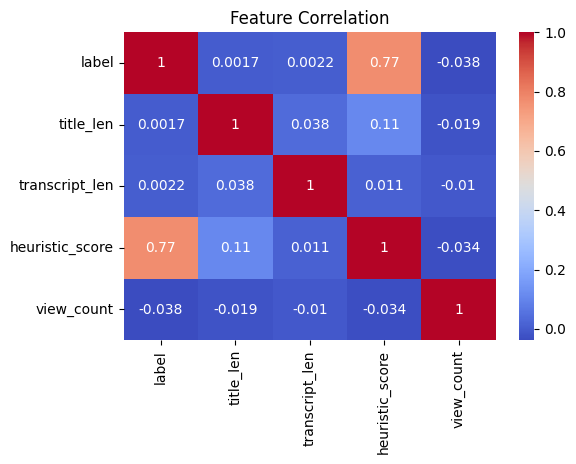

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["label","title_len","transcript_len","heuristic_score","view_count"]]
    .corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Feature Correlation")
plt.show()


In [11]:
# CELL 3 — Text embeddings (MuRIL — best for Hindi/Hinglish)
# Runtime: ~8-12 min on T4 for 2066 rows
import torch
from transformers import AutoTokenizer, AutoModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

MODEL_NAME = "google/muril-base-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
text_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def mean_pool(model_output, attention_mask):
    token_emb = model_output.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
    return (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

def embed_texts(texts, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="MuRIL embedding"):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=128, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = text_model(**enc)
        embs = mean_pool(out, enc["attention_mask"])
        all_embs.append(embs.cpu().float().numpy())
    return np.vstack(all_embs)

# Combine title + first 200 chars of description (most signal is here)
# Truncate title to 100 chars to avoid any padding waste
combined_texts = (
    df["title"].str[:100].fillna("") + " [SEP] " +
    df["description"].str[:200].fillna("")
).tolist()

X_text = embed_texts(combined_texts)  # shape: (2066, 768)
print(f"Text embeddings shape: {X_text.shape}")
from sklearn.preprocessing import normalize
X_text = normalize(X_text)
np.save("/content/X_text.npy", X_text)
print("Saved → /content/X_text.npy")

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
MuRIL embedding: 100%|██████████| 65/65 [00:13<00:00,  4.80it/s]

Text embeddings shape: (2066, 768)
Saved → /content/X_text.npy


In [12]:
# CELL 4 — Thumbnail embeddings (CLIP ViT-B/32)
# Runtime: ~5-7 min on T4
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(DEVICE).eval()

def embed_thumbnails(paths, batch_size=64):
    all_embs = []
    for i in tqdm(range(0, len(paths), batch_size), desc="CLIP embedding"):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                img = clip_preprocess(Image.open(p).convert("RGB"))
            except Exception:
                img = torch.zeros(3, 224, 224)  # black fallback for missing
            imgs.append(img)
        batch_tensor = torch.stack(imgs).to(DEVICE)
        with torch.no_grad():
            embs = clip_model.encode_image(batch_tensor)
        all_embs.append(embs.cpu().float().numpy())
    return np.vstack(all_embs)

thumb_paths = df["thumb_local"].tolist()
X_img = embed_thumbnails(thumb_paths)  # shape: (2066, 512)
from sklearn.preprocessing import normalize
X_img = normalize(X_img)
print(f"Image embeddings shape: {X_img.shape}")
np.save("/content/X_img.npy", X_img)
print("Saved → /content/X_img.npy")

CLIP embedding: 100%|██████████| 33/33 [00:44<00:00,  1.36s/it]

Image embeddings shape: (2066, 512)
Saved → /content/X_img.npy


In [13]:
# CELL 5 — Structured metadata features (12-d hand-crafted)
import isodate, re

HINDI_BAIT = [
    "सच्चाई","खुलासा","धमाका","तबाही","चौंकाने","हैरान","क्या हुआ",
    "आप नहीं जानते","सामने आई","बड़ा खुलासा","सनसनी","विस्फोट",
    "shocking","exposed","leaked","you won't believe","watch till end",
    "must watch","aakhir","finally","viral","mind-blowing","breaking",
    "exclusive","secret","truth","reality","reveals","सच","झूठ","असली"
]

def parse_duration(d):
    try:
        return isodate.parse_duration(str(d)).total_seconds()
    except:
        return 0.0

def meta_features(row):
    title    = str(row.get("title",""))
    t_lower  = title.lower()
    views    = max(float(row.get("view_count", 0) or 0), 1)
    likes    = float(row.get("like_count",   0) or 0)
    comments = float(row.get("comment_count",0) or 0)
    dur      = parse_duration(row.get("duration",""))
    tags_str = str(row.get("tags",""))

    caps_ratio  = sum(1 for c in title if c.isupper()) / max(len(title),1)
    emoji_count = len(re.findall(r'[\U00010000-\U0010ffff]', title))
    bait_hits   = sum(1 for w in HINDI_BAIT if w in t_lower)
    has_q       = int("?" in title)
    has_excl    = int("!" in title)
    tag_count   = len([t for t in tags_str.split(",") if t.strip()])
    title_len   = len(title)
    h_score     = float(row.get("heuristic_score", 0) or 0)

    return [
        np.log1p(views),               # log views
        likes / views,                 # engagement rate
        comments / views,              # comment rate
        min(dur / 3600, 24),           # duration in hours, capped
        title_len / 100,               # normalised title length
        caps_ratio,                    # caps proportion
        min(emoji_count / 5, 1),       # normalised emoji count
        min(bait_hits / 5, 1),         # normalised bait word hits
        has_q,                         # has question mark
        has_excl,                      # has exclamation
        min(tag_count / 20, 1),        # normalised tag count
        h_score / 10,                  # normalised heuristic score
    ]

X_meta = np.array([meta_features(row) for _, row in tqdm(
    df.iterrows(), total=len(df), desc="Meta features"
)], dtype=np.float32)

print(f"Meta features shape: {X_meta.shape}")
np.save("/content/X_meta.npy", X_meta)
print("Saved → /content/X_meta.npy")

Meta features: 100%|██████████| 2066/2066 [00:00<00:00, 9438.14it/s]

Meta features shape: (2066, 12)
Saved → /content/X_meta.npy


In [14]:
!pip install isodate

In [15]:
# CELL 6 — Fuse all three modalities
X_text = np.load("/content/X_text.npy")   # (2066, 768)
X_img  = np.load("/content/X_img.npy")    # (2066, 512)
X_meta = np.load("/content/X_meta.npy")   # (2066, 12)

# L2-normalise text and image embeddings before fusion
# This prevents the 768-d text from dominating the 12-d meta
from sklearn.preprocessing import normalize
X_text_n = normalize(X_text)
X_img_n  = normalize(X_img)
X_meta_n = normalize(X_meta)

X_all = np.hstack([X_text_n, X_img_n, X_meta_n])  # (2066, 1292)
y     = df["label"].values

print(f"Fused feature matrix: {X_all.shape}")
print(f"Label distribution  : {np.bincount(y)}")  # [1427, 639]

# Shuffle data (important before training)
from sklearn.utils import shuffle
X_all, y = shuffle(X_all, y, random_state=42)

print("Feature sample:", X_all[0][:10])

np.save("/content/X_text_n.npy", X_text_n)
np.save("/content/X_img_n.npy", X_img_n)
np.save("/content/X_meta_n.npy", X_meta_n)

np.save("/content/X_all.npy", X_all)
np.save("/content/y.npy", y)

Fused feature matrix: (2066, 1292)
Label distribution  : [1427  639]
Feature sample: [-0.00451808  0.00283549  0.00077795 -0.02769735 -0.00371841  0.00057813
 -0.00710542  0.00091728 -0.00034912 -0.00120476]


In [16]:
# CELL 7 — XGBoost training with 5-fold CV + class balancing
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
import pickle

X = np.load("/content/X_all.npy")
y = np.load("/content/y.npy")

# scale_pos_weight handles 1427:639 imbalance natively in XGBoost
# = count(negative) / count(positive)
spw = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {spw:.3f}")

clf = XGBClassifier(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.7,
    min_child_weight   = 3,
    gamma              = 0.1,
    scale_pos_weight   = spw,     # ← handles imbalance
    use_label_encoder  = False,
    eval_metric        = "logloss",
    tree_method        = "hist",
    device             = "cuda",  # T4 on Colab
    random_state       = 42,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
    callbacks=[
        __import__("xgboost").callback.EarlyStopping(
            rounds=30,
            save_best=True
        )
    ],
)

    preds = clf.predict(X_val)
    proba = clf.predict_proba(X_val)[:, 1]

    auc  = roc_auc_score(y_val, proba)
    f1   = f1_score(y_val, preds, average="macro")
    fold_results.append({"fold": fold+1, "auc": auc, "f1_macro": f1})
    print(f"Fold {fold+1}  AUC={auc:.4f}  F1-macro={f1:.4f}")
    print(classification_report(y_val, preds,
          target_names=["not_clickbait","clickbait"], digits=3))

results_df = pd.DataFrame(fold_results)
print("\n── Cross-validation summary ──────────────────────────")
print(results_df.describe().loc[["mean","std"]])

# ── Retrain on full data for final model ──────────────────
clf.fit(X, y)
pickle.dump(clf, open("/content/clickbait_xgb_v1.pkl", "wb"))
print("\nFinal model saved → /content/clickbait_xgb_v1.pkl")

scale_pos_weight: 2.233
[17:44:04] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

Fold 1  AUC=0.9914  F1-macro=0.9638
               precision    recall  f1-score   support

not_clickbait      0.989     0.965     0.977       286
    clickbait      0.926     0.977     0.951       128

     accuracy                          0.969       414
    macro avg      0.958     0.971     0.964       414
 weighted avg      0.970     0.969     0.969       414

[17:44:34] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

Fold 2  AUC=0.9939  F1-macro=0.9748
               precision    recall  f1-score   support

not_clickbait      0.993     0.975     0.984       285
    clickbait      0.947     0.984     0.966       128

     accuracy                          0.978       413
    macro avg      0.970     0.980     0.975       413
 weighted avg      0.979     0.978     0.978       413

[17:45:09] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } a

In [17]:
clf.save_model("/content/clickbait_xgb_v1.json")

[17:51:29] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

── Hold-out test (20%) ──────────────────────────────
               precision    recall  f1-score   support

not_clickbait     0.9857    0.9650    0.9753       286
    clickbait     0.9254    0.9688    0.9466       128

     accuracy                         0.9662       414
    macro avg     0.9555    0.9669    0.9609       414
 weighted avg     0.9671    0.9662    0.9664       414

AUC-ROC : 0.9952


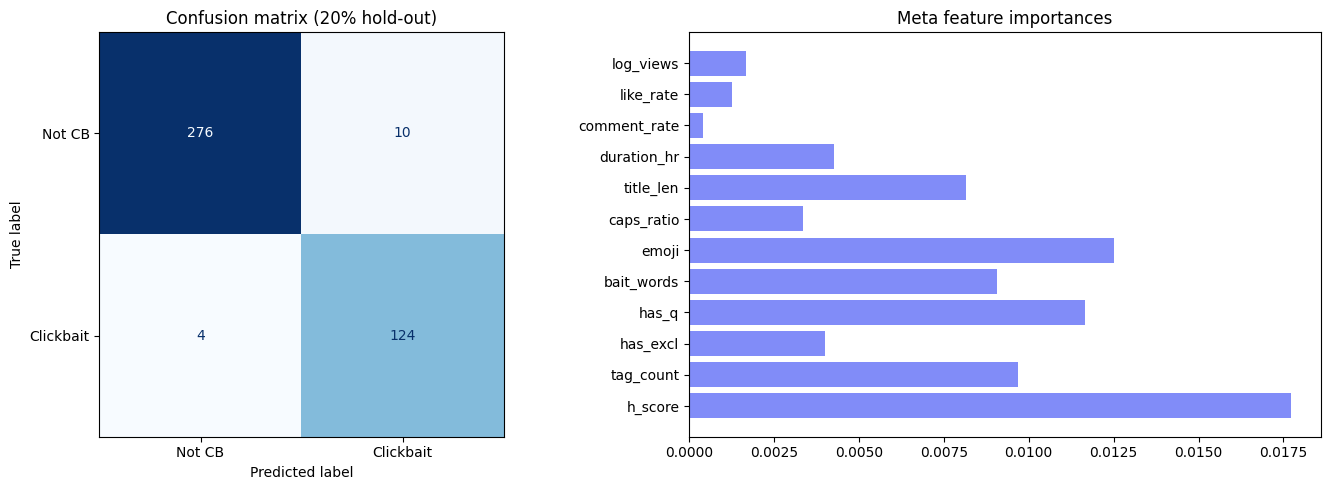

In [18]:
# CELL 8 — Evaluation plots
from sklearn.model_selection import train_test_split

# Hold-out eval on 20% for honest final numbers
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
clf_eval = XGBClassifier(**clf.get_params())
clf_eval.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
             early_stopping_rounds=30, verbose=False)

y_pred  = clf_eval.predict(X_te)
y_proba = clf_eval.predict_proba(X_te)[:, 1]

print("── Hold-out test (20%) ──────────────────────────────")
print(classification_report(y_te, y_pred,
      target_names=["not_clickbait","clickbait"], digits=4))
print(f"AUC-ROC : {roc_auc_score(y_te, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not CB","Clickbait"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (20% hold-out)")

# Feature importance — top 30 meta + embedding dims
importances = clf_eval.feature_importances_
# Only meaningful to plot meta features (last 12) by name
meta_names = [
    "log_views","like_rate","comment_rate","duration_hr","title_len",
    "caps_ratio","emoji","bait_words","has_q","has_excl","tag_count","h_score"
]
meta_imp = importances[-12:]
axes[1].barh(meta_names, meta_imp, color="#818cf8")
axes[1].set_title("Meta feature importances")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("/content/eval_plots.png", dpi=120)
plt.show()

In [19]:
import zipfile, json

# Save feature config so inference can reproduce the exact pipeline
feature_config = {
    "version"        : "1.0",
    "text_model"     : "google/muril-base-cased",
    "image_model"    : "ViT-B-32 openai",
    "text_dim"       : 768,
    "image_dim"      : 512,
    "meta_dim"       : 12,
    "total_dim"      : 1292,
    "label_map"      : {"0": "not_clickbait", "1": "clickbait"},
    "threshold"      : 0.5,
    "normalize_text" : True,
    "normalize_img"  : True,
    "meta_features"  : [
        "log_views","like_rate","comment_rate","duration_hr","title_len",
        "caps_ratio","emoji","bait_words","has_q","has_excl","tag_count","h_score"
    ]
}
json.dump(feature_config, open("/content/feature_config.json","w"), indent=2)

# Zip everything into one download
with zipfile.ZipFile("/content/clickbait_model_package.zip","w") as z:
    z.write("/content/clickbait_xgb_v1.pkl",  "clickbait_xgb_v1.pkl")
    z.write("/content/feature_config.json",    "feature_config.json")

print("Packaged → /content/clickbait_model_package.zip")

# Download to local machine
from google.colab import files
files.download("/content/clickbait_model_package.zip")
files.download("/content/eda.png")
files.download("/content/eval_plots.png")

Packaged → /content/clickbait_model_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>